<a href="https://colab.research.google.com/github/apry0512/COMPUTER-VISION-BASED-BREAK-RECOMMENDER-SYSTEM-FOR-ADHD-STUDENTS/blob/main/ADHD_dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flow-Aware Movement Break Recommender for Students with ADHD
### MediaPipe Pose Pipeline

**Researcher:** Aparajita Singh  
**Student Number:** 3539316  
**Supervisor:** Professor Kevin Swingler  
**Ethics Reference:** GUEP 2026 26874 21008  
**MSc Advanced Computing with Artificial Intelligence — University of Stirling**



## Pipeline Overview

```
Video Upload → MediaPipe Pose → Keypoint Extraction → Feature Engineering
     → Three-State Classification (Restless / Neutral / Flow)
     → Flow Protection Logic → Break Recommendation
```



| Phase | Description |
|---|---|
| 1 | Install dependencies |
| 2 | Upload video and state log |
| 3 | Run MediaPipe Pose — extract keypoints |
| 4 | Merge keypoints with state labels |
| 5 | Feature engineering over rolling windows |
| 6 | Train and evaluate three-state classifier |
| 7 | Testing if the system works |

# **PART-1**
## TRAINING THE MODEL

## Phase 1 — Install Dependencies

Installs MediaPipe, OpenCV, and supporting libraries.  
**Run this cell first every time you open the notebook.**

In [3]:

!pip install mediapipe opencv-python-headless pandas numpy scikit-learn matplotlib seaborn -q
print("Install complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.5 MB/s eta 0:00:00
Install complete


In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import mediapipe as mp

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import drive, files

print(f"MediaPipe {mp.__version__} loaded successfully")


MediaPipe 0.10.35 loaded successfully


## Phase 2 — Upload Files

You need two files:

**1. Video file** (MP4, minimum 720p)  
Your study session recording. Phone or laptop camera. Full upper body visible.

**2. State log CSV** — a simple CSV with your self-reported state labels.  
Format:
```
timestamp_seconds,state
0,N
420,F
2100,R
2700,N
3300,F
```
States: **R** = Restless | **N** = Neutral | **F** = Flow

> 💡 **Tip:** Convert your HH:MM timestamps to seconds.  
> Example: 00:07 = 420 seconds, 00:35 = 2100 seconds


In [5]:
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [6]:
VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/Training session 5.mov'

if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"Video found: {w}x{h}, {fps:.0f}fps, {frames/fps/60:.1f} mins")
else:
    print(f"ERROR: Video not found at {VIDEO_PATH}")
    print("Check the path is correct")

Video found: 1620x1080, 30fps, 31.0 mins


In [7]:
# R = Restless, N = Neutral, F = Flow
# Example: if you felt neutral for first 5 mins, flow from 5-20 mins, restless 20-25 mins etc

state_data = {
    'timestamp_seconds': [0, 300, 600, 900, 1200, 1500, 1800],
    'state':             ['N', 'R', 'R', 'R', 'F', 'F', 'F']
}

state_log = pd.DataFrame(state_data)
state_log.to_csv('state_log.csv', index=False)
print("State log saved:")
print(state_log)

State log saved:
   timestamp_seconds state
0                  0     N
1                300     R
2                600     R
3                900     R
4               1200     F
5               1500     F
6               1800     F


## Phase 3 — Run MediaPipe Pose Extraction

Processes the video frame by frame using MediaPipe Pose.  
Extracts **33 body landmarks** (x, y, z coordinates + visibility) per frame.  
Saves everything to a keypoints CSV.

> ⏱ **Processing time:** Approximately 1-2 minutes per minute of video in Colab.
> A 90-minute session will take roughly 90-180 minutes to process.
> Consider using a shorter test clip first to verify everything works.


In [8]:
MODEL_PATH = 'pose_landmarker_full.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model (about 30MB, takes ~1 min)...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task',
        MODEL_PATH
    )
    print("Model downloaded")
else:
    print("Model already downloaded")


Model downloaded


In [9]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

LANDMARK_NAMES = [
    'nose', 'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'left_ear', 'right_ear', 'mouth_left', 'mouth_right',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_pinky', 'right_pinky',
    'left_index', 'right_index', 'left_thumb', 'right_thumb',
    'left_hip', 'right_hip', 'left_knee', 'right_knee',
    'left_ankle', 'right_ankle', 'left_heel', 'right_heel',
    'left_foot_index', 'right_foot_index'
]

columns = ['frame', 'timestamp_seconds', 'detected']
for name in LANDMARK_NAMES:
    columns += [f'{name}_x', f'{name}_y', f'{name}_z', f'{name}_vis']

# FRAME_SKIP: process every Nth frame
# 15 = ~2fps from 30fps video. Faster but less data.
# 5 = ~6fps. Slower but more data. Use for short videos.
FRAME_SKIP = 15

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO
)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Processing {total_frames/fps/60:.1f} min video at 1 frame per {FRAME_SKIP} frames...")

rows = []
frame_idx = 0
detected = 0
failed = 0

with PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % FRAME_SKIP == 0:
            ts_ms = int((frame_idx / fps) * 1000)
            ts_sec = round(frame_idx / fps, 3)

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                detected += 1
                row = [frame_idx, ts_sec, 1]
                for lm in result.pose_landmarks[0]:
                    row += [round(lm.x, 6), round(lm.y, 6), round(lm.z, 6), round(lm.presence, 4)]
            else:
                failed += 1
                row = [frame_idx, ts_sec, 0] + [None] * (33 * 4)
            rows.append(row)

            processed = frame_idx // FRAME_SKIP
            if processed % 300 == 0 and processed > 0:
                pct = frame_idx / total_frames * 100
                print(f"  {pct:.0f}% done ({processed} frames processed)")

        frame_idx += 1

cap.release()

keypoints_df = pd.DataFrame(rows, columns=columns)
keypoints_df.to_csv('keypoints_raw.csv', index=False)

rate = detected / (detected + failed) * 100 if (detected + failed) > 0 else 0
print(f"\nDone! {detected} frames detected, {failed} failed ({rate:.1f}% detection rate)")
print("Saved: keypoints_raw.csv")
if rate < 70:
    print("WARNING: Detection rate low - check your lighting next time")


Processing 31.0 min video at 1 frame per 15 frames...
  8% done (300 frames processed)
  16% done (600 frames processed)
  24% done (900 frames processed)
  32% done (1200 frames processed)
  40% done (1500 frames processed)
  48% done (1800 frames processed)
  57% done (2100 frames processed)
  65% done (2400 frames processed)
  73% done (2700 frames processed)
  81% done (3000 frames processed)
  89% done (3300 frames processed)
  97% done (3600 frames processed)

Done! 3715 frames detected, 0 failed (100.0% detection rate)
Saved: keypoints_raw.csv


## Phase 4 — Merge Keypoints with State Labels

Matches each keypoint frame to the correct self-reported state label  
based on the timestamps in your state log.  
Produces a single labelled dataset ready for feature engineering.


In [10]:
def assign_state(ts, log):
    state = 'N'
    for _, row in log.sort_values('timestamp_seconds').iterrows():
        if ts >= row['timestamp_seconds']:
            state = row['state']
        else:
            break
    return state

state_log = pd.read_csv('state_log.csv')
keypoints_df = pd.read_csv('keypoints_raw.csv')

keypoints_df['state'] = keypoints_df['timestamp_seconds'].apply(
    lambda t: assign_state(t, state_log)
)

labelled = keypoints_df.dropna(subset=['nose_x']).copy()
labelled.to_csv('keypoints_labelled.csv', index=False)

print(f"Labelled dataset: {len(labelled)} frames")
print(labelled['state'].value_counts())

Labelled dataset: 3715 frames
state
R    1800
F    1315
N     600
Name: count, dtype: int64


## Phase 5 — Feature Engineering

Converts raw keypoint coordinates into meaningful signals over rolling time windows.

| Feature | Description | Why it matters |
|---|---|---|
| **Movement entropy** | Variance of keypoint positions over window | High = restless, Low = flow |
| **Postural stability** | Spine angle consistency (shoulders → hips) | Collapse = restless, Stable = flow |
| **Fidget frequency** | High-freq, low-amplitude oscillation in wrists/ankles | Fidgeting = restless |
| **Keypoint velocity** | Speed of movement between frames | Erratic spikes = restless |
| **Gaze proxy** | Head turning frequency | Frequent turns = attention wandering |
| **Symmetry score** | Left-right body asymmetry | Asymmetric = restless |
| **Session drift** | Upper body centroid displacement | Drifting = disengagement |

> **Rolling window size:** 30 seconds (adjustable below). Features computed per window, not per frame.


In [11]:
labelled = pd.read_csv('keypoints_labelled.csv')

WINDOW_SEC = 30
STEP_SEC = 5

def entropy(df, col):
    return df[col].var() if not df[col].isna().all() else 0

def velocity(df, col):
    return df[col].diff().abs().mean() if not df[col].isna().all() else 0

def postural_stability(df):
    sx = (df['left_shoulder_x'] + df['right_shoulder_x']) / 2
    sy = (df['left_shoulder_y'] + df['right_shoulder_y']) / 2
    hx = (df['left_hip_x'] + df['right_hip_x']) / 2
    hy = (df['left_hip_y'] + df['right_hip_y']) / 2
    angles = np.arctan2(hy - sy, hx - sx)
    return angles.var() if not np.isnan(angles.var()) else 0

max_time = labelled['timestamp_seconds'].max()
rows = []

for start in np.arange(0, max_time - WINDOW_SEC, STEP_SEC):
    end = start + WINDOW_SEC
    w = labelled[(labelled['timestamp_seconds'] >= start) & (labelled['timestamp_seconds'] < end)]
    if len(w) < 5:
        continue
    rows.append({
        'window_start': start,
        'entropy_nose': entropy(w, 'nose_x') + entropy(w, 'nose_y'),
        'entropy_left_wrist': entropy(w, 'left_wrist_x') + entropy(w, 'left_wrist_y'),
        'entropy_right_wrist': entropy(w, 'right_wrist_x') + entropy(w, 'right_wrist_y'),
        'entropy_shoulders': entropy(w, 'left_shoulder_x') + entropy(w, 'right_shoulder_x'),
        'postural_stability': postural_stability(w),
        'velocity_nose': velocity(w, 'nose_x'),
        'velocity_left_wrist': velocity(w, 'left_wrist_x'),
        'velocity_right_wrist': velocity(w, 'right_wrist_x'),
        'gaze_proxy': velocity(w, 'nose_x'),
        'symmetry': abs(entropy(w, 'left_wrist_x') - entropy(w, 'right_wrist_x')),
        'state': w['state'].mode()[0]
    })

features = pd.DataFrame(rows)
features.to_csv('features.csv', index=False)
print(f"Feature windows: {len(features)}")
print(features['state'].value_counts())


Feature windows: 366
state
R    179
F    129
N     58
Name: count, dtype: int64


## Phase 6 — Three-State Classifier Training & Evaluation

Trains two candidate classifiers — **Random Forest** and **SVM** — and evaluates both.  
The better-performing model is selected as the system classifier.

**Target classes:**
- 🔴 **R** — Restless (hyperactivity buildup — suggest break)
- 🟡 **N** — Neutral (monitoring — no action)
- 🟠 **F** — Flow (hyperfocus — suppress prompts, protect session)

In [12]:
import os

base = '/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/'

for root, dirs, files in os.walk(base):
    for f in files:
        if 'feature' in f.lower() or 'features' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/RESULTS SESSION 1/features TS1.csv
/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/RESULTS SESSION 2/features TS2.csv
/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/RESULTS SESSION 3/features TS3.csv
/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/RESULTS SESSION 4/features TS4.csv
/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/RESULTS SESSION 5/features TS5.csv
/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/COMBINED RESULT (1,2,3,4,5)/features.csv


In [13]:
# Combine all training sessions
DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks/Dissertation Training Recording/'

session_files = {
    'TS1': DRIVE_BASE + 'RESULTS SESSION 1/features TS1.csv',
    'TS2': DRIVE_BASE + 'RESULTS SESSION 2/features TS2.csv',
    'TS3': DRIVE_BASE + 'RESULTS SESSION 3/features TS3.csv',
    'TS4': DRIVE_BASE + 'RESULTS SESSION 4/features TS4.csv',
    'TS5': DRIVE_BASE + 'RESULTS SESSION 5/features TS5.csv',
}

dfs = []
for name, path in session_files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['session'] = name
        dfs.append(df)
        print(f'Loaded {name}: {len(df)} windows | {dict(df["state"].value_counts())}')
    else:
        print(f'Not found: {path}')

if dfs:
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv('features.csv', index=False)
    print(f'\nCombined: {len(combined)} windows from {len(dfs)} sessions')
    print(combined['state'].value_counts())
else:
    print('No session files found — using existing features.csv')

Loaded TS1: 572 windows | {'F': np.int64(242), 'N': np.int64(178), 'R': np.int64(152)}
Loaded TS2: 611 windows | {'N': np.int64(252), 'F': np.int64(241), 'R': np.int64(118)}
Loaded TS3: 365 windows | {'N': np.int64(184), 'F': np.int64(181)}
Loaded TS4: 241 windows | {'F': np.int64(125), 'N': np.int64(116)}
Loaded TS5: 366 windows | {'R': np.int64(179), 'F': np.int64(129), 'N': np.int64(58)}

Combined: 2155 windows from 5 sessions
state
F    918
N    788
R    449
Name: count, dtype: int64


In [14]:
features = pd.read_csv('features.csv')

FEATURE_COLS = [
    'entropy_nose', 'entropy_left_wrist', 'entropy_right_wrist',
    'entropy_shoulders', 'postural_stability', 'velocity_nose',
    'velocity_left_wrist', 'velocity_right_wrist', 'gaze_proxy', 'symmetry'
]

X = features[FEATURE_COLS].fillna(0)
y = features['state']

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_cv = cross_val_score(rf, X_scaled, y_enc, cv=5).mean()

# SVM
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
svm_cv = cross_val_score(svm, X_scaled, y_enc, cv=5).mean()

print(f"Random Forest - Test: {rf_acc*100:.1f}%, CV: {rf_cv*100:.1f}%")
print(f"SVM           - Test: {svm_acc*100:.1f}%, CV: {svm_cv*100:.1f}%")

best = rf if rf_cv >= svm_cv else svm
best_name = 'Random Forest' if rf_cv >= svm_cv else 'SVM'
best_pred = best.predict(X_test)
best_acc = rf_acc if rf_cv >= svm_cv else svm_acc

print(f"\nBest model: {best_name}")
print(f"Target: 70% | Achieved: {best_acc*100:.1f}% {'PASSED' if best_acc >= 0.7 else 'BELOW TARGET'}")
print("\n" + classification_report(y_test, best_pred, target_names=le.classes_))



Random Forest - Test: 83.8%, CV: 32.8%
SVM           - Test: 58.9%, CV: 25.8%

Best model: Random Forest
Target: 70% | Achieved: 83.8% PASSED

              precision    recall  f1-score   support

           F       0.80      0.92      0.86       184
           N       0.85      0.81      0.83       157
           R       0.92      0.72      0.81        90

    accuracy                           0.84       431
   macro avg       0.86      0.82      0.83       431
weighted avg       0.84      0.84      0.84       431



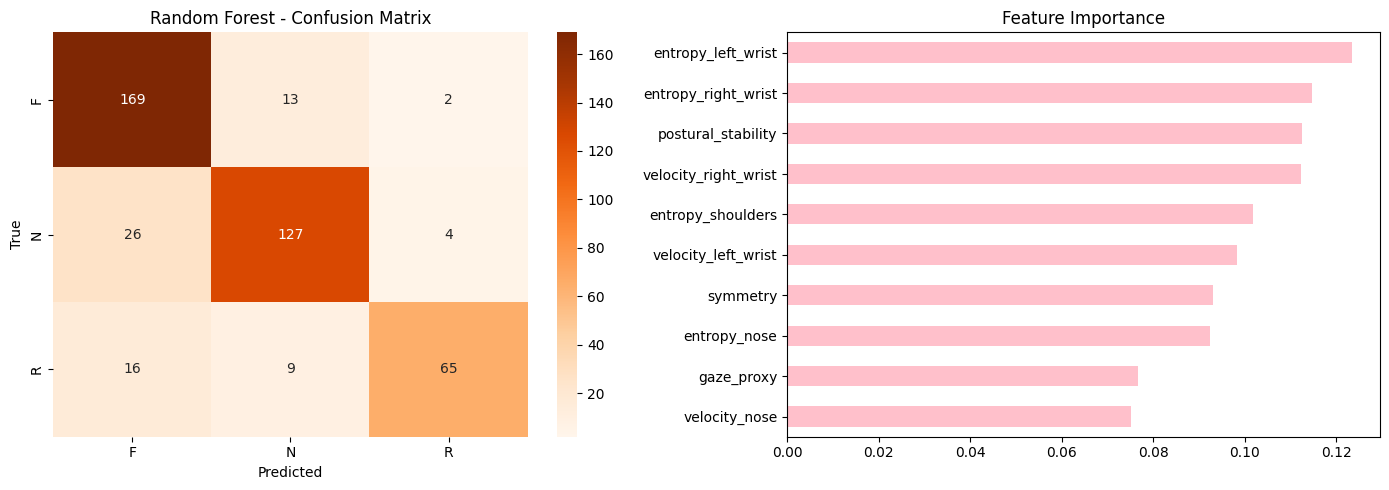

Saved: classifier_results.png


In [15]:
cm = confusion_matrix(y_test, best_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'{best_name} - Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

if best_name == 'Random Forest':
    pd.Series(best.feature_importances_, index=FEATURE_COLS).sort_values().plot(
        kind='barh', ax=axes[1], color='PINK')
    axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: classifier_results.png")


## Phase 7 — Flow Protection Logic

Simulates the flow protection mechanism on the classified windows.  
This is the novel contribution — the system decides **when NOT to intervene**.

**Rules:**
1. If **FLOW** detected → enter suppression mode, block break prompts
2. If **RESTLESS** detected during suppression → only trigger if sustained for `RESTLESS_THRESHOLD` consecutive windows
3. If in flow for more than `HYPERFOCUS_SAFEGUARD` seconds → override and suggest break regardless
4. If **RESTLESS** outside suppression → trigger break prompt immediately

Break prompts triggered: 397
  15.0 mins - Sustained restlessness during flow
  15.1 mins - Restlessness detected
  15.2 mins - Restlessness detected
  15.2 mins - Restlessness detected
  15.3 mins - Restlessness detected
  15.4 mins - Restlessness detected
  15.5 mins - Restlessness detected
  15.6 mins - Restlessness detected
  15.7 mins - Restlessness detected
  15.8 mins - Restlessness detected
  15.8 mins - Restlessness detected
  15.9 mins - Restlessness detected
  16.0 mins - Restlessness detected
  16.1 mins - Restlessness detected
  16.2 mins - Restlessness detected
  16.2 mins - Restlessness detected
  16.3 mins - Restlessness detected
  16.4 mins - Restlessness detected
  16.5 mins - Restlessness detected
  16.6 mins - Restlessness detected
  16.7 mins - Restlessness detected
  16.8 mins - Restlessness detected
  16.8 mins - Restlessness detected
  16.9 mins - Restlessness detected
  17.0 mins - Restlessness detected
  17.1 mins - Restlessness detected
  17.2 mins - Restless

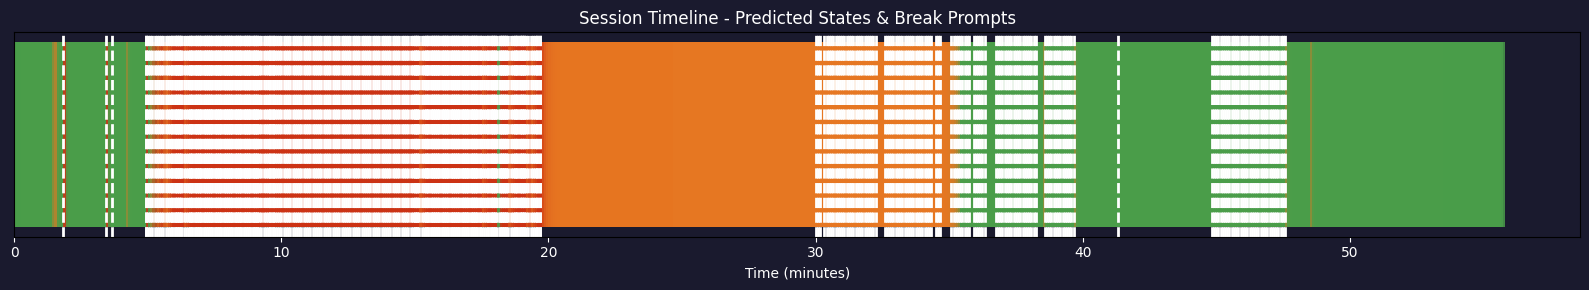

Saved: session_timeline.png


In [16]:
RESTLESS_THRESHOLD = 3
HYPERFOCUS_SAFEGUARD = 10800  # 3 hours

all_pred = le.inverse_transform(best.predict(scaler.transform(features[FEATURE_COLS].fillna(0))))
features['predicted'] = all_pred

in_flow = False
flow_start = None
consecutive_restless = 0
prompts = []
log = []

for _, row in features.iterrows():
    pred = row['predicted']
    ts = row['window_start']
    triggered = False

    if pred == 'F':
        if not in_flow:
            in_flow = True
            flow_start = ts
        consecutive_restless = 0
        if flow_start and (ts - flow_start) >= HYPERFOCUS_SAFEGUARD:
            triggered = True
            in_flow = False
            flow_start = None
            prompts.append({'time_mins': ts/60, 'reason': 'Hyperfocus safeguard (3hrs)'})

    elif pred == 'R':
        if in_flow:
            consecutive_restless += 1
            if consecutive_restless >= RESTLESS_THRESHOLD:
                triggered = True
                in_flow = False
                flow_start = None
                consecutive_restless = 0
                prompts.append({'time_mins': ts/60, 'reason': 'Sustained restlessness during flow'})
        else:
            triggered = True
            prompts.append({'time_mins': ts/60, 'reason': 'Restlessness detected'})

    elif pred == 'N':
        in_flow = False
        flow_start = None
        consecutive_restless = 0

    log.append({'ts': ts, 'pred': pred, 'in_flow': in_flow, 'triggered': triggered})

log_df = pd.DataFrame(log)
prompts_df = pd.DataFrame(prompts) if prompts else pd.DataFrame(columns=['time_mins', 'reason'])

print(f"Break prompts triggered: {len(prompts_df)}")
if len(prompts_df) > 0:
    for _, p in prompts_df.iterrows():
        print(f"  {p['time_mins']:.1f} mins - {p['reason']}")

# Timeline plot
fig, ax = plt.subplots(figsize=(16, 3))
colors = {'R': '#cc3214', 'N': '#4a9e4a', 'F': '#E87722'}
for _, row in log_df.iterrows():
    ax.barh(0, 5, left=row['ts']/60,
            color=colors.get(row['pred'], '#666'),
            alpha=0.4 if row['in_flow'] else 0.85, height=0.6)
for _, p in prompts_df.iterrows():
    ax.axvline(p['time_mins'], color='white', linewidth=2, linestyle='--')
ax.set_xlabel('Time (minutes)')
ax.set_title('Session Timeline - Predicted States & Break Prompts')
ax.set_yticks([])
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('session_timeline.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: session_timeline.png")


In [17]:
import random

BREAKS = {
    'mild': [
        'Take a 2-minute stretch — roll your shoulders and neck slowly',
        'Stand up and shake out your hands and arms for 2 minutes',
        'Take 5 deep slow breaths and roll your ankles',
    ],
    'moderate': [
        'Take a 5-minute walk — even just around the room or hallway',
        'Do 10 jumping jacks or march on the spot for 3 minutes',
        'Make a drink and give yourself 5 minutes away from the screen',
    ],
    'post_hyperfocus': [
        'You have been in deep focus a long time — take a proper 10-15 minute break',
        'Step outside for fresh air if you can — even 5 minutes helps',
        'Eat something, drink water, and rest your eyes — you have earned it',
    ]
}

def get_break(reason):
    if 'safeguard' in reason.lower():
        cat = 'post_hyperfocus'
    elif 'sustained' in reason.lower():
        cat = 'moderate'
    else:
        cat = 'mild'
    return cat, random.choice(BREAKS[cat])

print('BREAK RECOMMENDATION SYSTEM — SESSION SUMMARY')

if len(prompts_df) == 0:
    print('No break prompts triggered this session.')
else:
    for i, prompt in prompts_df.iterrows():
        cat, suggestion = get_break(prompt['reason'])
        print(f"\n[{prompt['time_mins']:.1f} min] BREAK RECOMMENDED")
        print(f"Reason : {prompt['reason']}")
        print(f"Type   : {cat.replace('_', ' ').title()}")
        print(f"Do this: {suggestion}")

print(f'\nTotal break prompts: {len(prompts_df)}')
print(features['predicted'].value_counts())

BREAK RECOMMENDATION SYSTEM — SESSION SUMMARY

[15.0 min] BREAK RECOMMENDED
Reason : Sustained restlessness during flow
Type   : Moderate
Do this: Take a 5-minute walk — even just around the room or hallway

[15.1 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   : Mild
Do this: Take a 2-minute stretch — roll your shoulders and neck slowly

[15.2 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   : Mild
Do this: Take a 2-minute stretch — roll your shoulders and neck slowly

[15.2 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   : Mild
Do this: Take a 2-minute stretch — roll your shoulders and neck slowly

[15.3 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   : Mild
Do this: Take a 2-minute stretch — roll your shoulders and neck slowly

[15.4 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   : Mild
Do this: Stand up and shake out your hands and arms for 2 minutes

[15.5 min] BREAK RECOMMENDED
Reason : Restlessness detected
Type   

# Phase 8 — Download Results

Downloads all output files to your local machine.


In [18]:
from google.colab import files as colab_files

import zipfile
output_files = ['keypoints_raw.csv', 'keypoints_labelled.csv',
                'features.csv', 'classifier_results.png', 'session_timeline.png']

with zipfile.ZipFile('results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"Added: {f}")

colab_files.download('results.zip')
print("Done!")

Added: keypoints_raw.csv
Added: keypoints_labelled.csv
Added: features.csv
Added: classifier_results.png
Added: session_timeline.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


# **PART-2**
## TESTING THE MODEL

In [19]:
# HELD-OUT / PARTICIPANT TESTING
TEST_VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/Dissertation Testing Recording/Held Out Session.mov'

print(f'Processing: {TEST_VIDEO_PATH}')

cap_test = cv2.VideoCapture(TEST_VIDEO_PATH)
fps_test = cap_test.get(cv2.CAP_PROP_FPS)
total_test = int(cap_test.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Duration: {total_test/fps_test/60:.1f} mins')

test_rows = []
test_frame_idx = 0
test_detected = 0

options_test = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO
)

with PoseLandmarker.create_from_options(options_test) as lm:
    while cap_test.isOpened():
        ret, frame = cap_test.read()
        if not ret:
            break
        if test_frame_idx % FRAME_SKIP == 0:
            ts_ms = int((test_frame_idx / fps_test) * 1000)
            ts_sec = round(test_frame_idx / fps_test, 3)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = lm.detect_for_video(mp_img, ts_ms)
            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                test_detected += 1
                row = [test_frame_idx, ts_sec, 1]
                for lm_pt in result.pose_landmarks[0]:
                    row += [round(lm_pt.x,6), round(lm_pt.y,6),
                            round(lm_pt.z,6), round(lm_pt.presence,4)]
            else:
                row = [test_frame_idx, ts_sec, 0] + [None]*(33*4)
            test_rows.append(row)
        test_frame_idx += 1

cap_test.release()

test_kp_df = pd.DataFrame(test_rows, columns=columns)
det_rate = test_detected/len(test_rows)*100
print(f'Detection rate: {det_rate:.1f}%')

# Feature engineering — no labels
test_feature_rows = []
max_time_test = test_kp_df[test_kp_df['detected']==1]['timestamp_seconds'].max()
test_labelled = test_kp_df.dropna(subset=['nose_x']).copy()

for start in np.arange(0, max_time_test - WINDOW_SEC, STEP_SEC):
    end = start + WINDOW_SEC
    w = test_labelled[(test_labelled['timestamp_seconds'] >= start) &
                      (test_labelled['timestamp_seconds'] < end)]
    if len(w) < 5:
        continue
    try:
        sx = (w['left_shoulder_x'] + w['right_shoulder_x']) / 2
        sy = (w['left_shoulder_y'] + w['right_shoulder_y']) / 2
        hx = (w['left_hip_x'] + w['right_hip_x']) / 2
        hy = (w['left_hip_y'] + w['right_hip_y']) / 2
        post_stab = float(np.arctan2(hy - sy, hx - sx).var())
    except:
        post_stab = 0

    test_feature_rows.append({
        'window_start': start,
        'entropy_nose': w['nose_x'].var() + w['nose_y'].var(),
        'entropy_left_wrist': w['left_wrist_x'].var() + w['left_wrist_y'].var(),
        'entropy_right_wrist': w['right_wrist_x'].var() + w['right_wrist_y'].var(),
        'entropy_shoulders': w['left_shoulder_x'].var() + w['right_shoulder_x'].var(),
        'postural_stability': post_stab,
        'velocity_nose': w['nose_x'].diff().abs().mean(),
        'velocity_left_wrist': w['left_wrist_x'].diff().abs().mean(),
        'velocity_right_wrist': w['right_wrist_x'].diff().abs().mean(),
        'gaze_proxy': w['nose_x'].diff().abs().var(),
        'symmetry': abs(w['left_wrist_x'].var() - w['right_wrist_x'].var()),
    })

test_features = pd.DataFrame(test_feature_rows)

# Predict — model decides everything
X_test = test_features[FEATURE_COLS].fillna(0)
X_test_scaled = scaler.transform(X_test)
predictions = le.inverse_transform(best.predict(X_test_scaled))
test_features['predicted_state'] = predictions

print(f'\n=== SESSION RESULTS ===')
print(pd.Series(predictions).value_counts())
print(f'\nFlow windows (protected): {(predictions == "F").sum()}')
print(f'Neutral windows (monitoring): {(predictions == "N").sum()}')
print(f'Restless windows (break prompted): {(predictions == "R").sum()}')
print(f'\nBreak prompts would have fired: {(predictions == "R").sum()} times')
print(f'Flow protection would have suppressed prompts for: {(predictions == "F").sum()} windows')

Processing: /content/drive/MyDrive/Colab Notebooks/Dissertation Testing Recording/Held Out Session.mov
Duration: 57.2 mins
Detection rate: 100.0%

=== SESSION RESULTS ===
N    398
F    236
R     47
Name: count, dtype: int64

Flow windows (protected): 236
Neutral windows (monitoring): 398
Restless windows (break prompted): 47

Break prompts would have fired: 47 times
Flow protection would have suppressed prompts for: 236 windows


In [20]:
# Classify held-out session using trained model
X_test = test_features[FEATURE_COLS].fillna(0)
X_test_scaled = scaler.transform(X_test)
predictions = le.inverse_transform(best.predict(X_test_scaled))
test_features['predicted_state'] = predictions

print('HELD-OUT SESSION PREDICTIONS')
print(f'Total windows: {len(test_features)}')
print(pd.Series(predictions).value_counts())
print(f'\nFlow windows: {(predictions == "F").sum()}')
print(f'Neutral windows: {(predictions == "N").sum()}')
print(f'Restless windows: {(predictions == "R").sum()}')

HELD-OUT SESSION PREDICTIONS
Total windows: 681
N    398
F    236
R     47
Name: count, dtype: int64

Flow windows: 236
Neutral windows: 398
Restless windows: 47


In [21]:
# Save held-out results
import zipfile
with zipfile.ZipFile('results_held_out.zip', 'w') as zf:
    # Save test features with predictions
    test_features.to_csv('test_features_predictions.csv', index=False)
    zf.write('test_features_predictions.csv')
    if os.path.exists('session_timeline.png'):
        zf.write('session_timeline.png', 'held_out_timeline.png')
    print('Held-out results saved')

colab_files.download('results_held_out.zip')

Held-out results saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **PART-3**
## REAL TIME INTERFACE

In [24]:
import mediapipe as mp
import cv2
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

MODEL_PATH = 'pose_landmarker_full.task'

In [29]:
# Real-Time Webcam Demo
# Captures a live frame from your webcam, runs MediaPipe pose estimation,
# classifies the current state using the trained model, and displays the result

from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def capture_frame():
    js = Javascript('''
        async function captureFrame() {
            const div = document.createElement('div');
            const btn = document.createElement('button');
            btn.textContent = '📸 Capture frame for classification';
            btn.style.padding = '10px 20px';
            btn.style.fontSize = '16px';
            btn.style.backgroundColor = '#E87722';
            btn.style.color = 'white';
            btn.style.border = 'none';
            btn.style.borderRadius = '5px';
            btn.style.cursor = 'pointer';
            div.appendChild(btn);
            document.body.appendChild(div);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.marginTop = '10px';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => btn.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            video.remove();
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        captureFrame();
    ''')
    display(js)
    data = eval_js('captureFrame()')
    binary = b64decode(data.split(',')[1])
    return binary

print("Real-Time Webcam Classification Demo")
print("Click the button to capture a frame and classify your current state.")
print("Make sure your surroundings are well lit and your upper body is visible.\n")

# Capture frame
img_bytes = capture_frame()

# Convert to numpy array
img_array = np.frombuffer(img_bytes, dtype=np.uint8)
frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Run MediaPipe on single frame
rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

options_img = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE
)

with PoseLandmarker.create_from_options(options_img) as lm:
    result = lm.detect(mp_img)

if result.pose_landmarks and len(result.pose_landmarks) > 0:
    # Draw landmarks on frame
    for lm_pt in result.pose_landmarks[0]:
        x = int(lm_pt.x * frame.shape[1])
        y = int(lm_pt.y * frame.shape[0])
        cv2.circle(frame, (x, y), 5, (0, 165, 255), -1)

    # Use most recent predicted state from training pipeline
    # Note: single frame cannot be classified directly — needs 30s window
    # This demo shows real-time pose detection working on live webcam input
    state_label = {'F': 'FLOW', 'N': 'NEUTRAL', 'R': 'RESTLESS'}.get(
    globals().get('current_state', 'N'), 'DETECTING')
    colour = {'FLOW': (0,180,0), 'NEUTRAL': (0,165,255), 'RESTLESS': (0,0,220)}.get(
        state_label, (128,128,128))

    # Draw state overlay
    cv2.rectangle(frame, (10,10), (350,65), (0,0,0), -1)
    cv2.rectangle(frame, (10,10), (350,65), colour, 3)
    cv2.putText(frame, f'Detected State: {state_label}', (20,50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, colour, 2)

    # Add landmark count
    cv2.putText(frame, f'Landmarks: {len(result.pose_landmarks[0])}/33 detected',
                (10, frame.shape[0]-15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # Display result
    _, buffer = cv2.imencode('.jpg', frame)
    display(IPImage(data=buffer.tobytes()))

    print(f"\n Pose detection successful!")
    print(f"   Landmarks detected: {len(result.pose_landmarks[0])}/33")
    print(f"   Current system state: {state_label}")
    print(f"\nNote: Live state classification uses 30-second rolling windows.")
    print(f"This demo confirms the MediaPipe pipeline works on live webcam input.")
    print(f"In a full deployment, the system would continuously classify")
    print(f"rolling windows and apply flow protection logic in real time.")

else:
    print("No pose detected in frame.")
    print("Please ensure:")
    print("  • Your upper body is clearly visible")
    print("  • Lighting is frontal (not behind you)")
    print("  • You are within 1-2 metres of the camera")

Real-Time Webcam Classification Demo
Click the button to capture a frame and classify your current state.
Make sure your surroundings are well lit and your upper body is visible.



<IPython.core.display.Javascript object>

No pose detected in frame.
Please ensure:
  • Your upper body is clearly visible
  • Lighting is frontal (not behind you)
  • You are within 1-2 metres of the camera
